# Анализ метрик и юнит-экономики приложения Procrastinate Pro+

> Кратко: исследование окупаемости маркетинговых вложений после запуска нового спортивного контента. Цель — выявить причины стагнации выручки при росте аудитории и дать рекомендации по оптимизации каналов привлечения.

## Бизнес-контекст

**Продукт**: Procrastinate Pro+ — приложение с развлекательным контентом (видео, подкасты, блоги) по подписке. Пользователи могут комбинировать пакеты контента разной цены и наполнения.

**Событие**: В начале лета 2024 года запущен новый спортивный контент. Параллельно скорректирована маркетинговая стратегия для привлечения аудитории, интересующейся ЗОЖ.

**Проблема**: После запуска интерес к продукту вырос, но выручка стагнирует. При этом бизнес-модель требует окупаемости привлечения за 28 дней.

**Задача анализа**:
1.  Оценить юнит-экономику продукта в динамике (28-дневный горизонт)
2.  Выявить причины расхождения между ростом аудитории и стагнацией выручки
3.  Сегментировать каналы привлечения по окупаемости (CAC, LTV, ROI)
4.  Сформулировать рекомендации по оптимизации маркетингового бюджета

## Данные и методология

Анализ проведён на основе трёх датасетов, описывающих поведение пользователей, транзакции и маркетинговые расходы за период апрель–ноябрь 2024:

| Датасет | Описание | Ключевые поля |
|---------|----------|---------------|
| `ppro_visits.csv` | Сессии пользователей: кто, откуда, когда и как долго пользовался приложением | `user_id`, `channel`, `device`, `region`, `session_start`, `session_end` |
| `ppro_orders.csv` | Покупки и выручка: кто, когда и сколько заплатил | `user_id`, `event_dt`, `revenue` |
| `ppro_costs.csv` | Маркетинговые расходы по каналам в динамике | `dt`, `channel`, `costs` |

**Ключевые допущения**:
- Период наблюдения: 28 дней с момента регистрации пользователя (стандарт окупаемости для продукта)
- Канал привлечения определяется по первой сессии пользователя
- Выручка считается по факту оплаты (модель подписки + пакетные покупки)

**Методология**:
1.  **Когортный анализ** по неделе привлечения для оценки динамики метрик
2.  **Расчёт юнит-экономики**: CAC, LTV₂₈, ROI₂₈, Payback Period
3.  **Сегментация по каналам**: сравнение эффективности источников трафика
4.  **Визуализация**: тепловые карты удержания, графики LTV/CAC, воронки конверсии

> **Примечание**: Исходные данные анонимизированы. Для воспроизведения анализа достаточно структуры таблиц, описанной выше.


## Загрузка и предобработка данных

Качество когортного анализа и расчёта юнит-экономики (CAC, LTV, ROI) напрямую зависит от чистоты данных. Предобработка необходима для исключения артефактов сбора и технических несоответствий, которые могут исказить метрики.

### План предобработки

| Направление | Что проверим / приведём к единому формату |
|-------------|------------------------------------------|
| **Временные метки** | `session_start`, `session_end`, `event_dt` → `datetime` для корректного расчёта интервалов |
| **Период анализа** | Фильтрация по датам регистрации (01.04–30.11.2024) для согласованности с маркетинговыми данными |
| **Целостность сессий** | Удаление дубликатов, проверка `session_end ≥ session_start` |
| **Валидация выручки** | Проверка `revenue ≥ 0`, фильтрация экстремальных выбросов |
| **Каналы привлечения** | Определение канала по первой сессии пользователя для корректного расчёта CAC |
| **Горизонт анализа** | Ограничение данных 28 днями после регистрации (требование бизнес-модели) |

### Ожидаемый результат
После предобработки будут получены согласованные датасеты, готовые к:
- Когортному анализу по неделе привлечения
- Расчёту метрик вовлечённости (Retention, Stickiness)
- Оценке юнит-экономики (CAC, LTV₂₈, ROI₂₈) по каналам

In [ ]:
# Импорт библиотек для анализа юнит-экономики и визуализации

# Цель: подготовить инструментарий для расчёта когортных метрик,
# статистической проверки гипотез и наглядной презентации результатов
from scipy import stats as st
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib.colors as mcolors
import datetime
import math

# Настройка отображения: показывать больше колонок при просмотре датафреймов
# Упрощает отладку и валидацию данных на этапе предобработки
pd.options.display.max_columns = 80

# Загрузка исходных данных для анализа

# Оцениваем влияние запуска спортивного контента и изменения
# маркетинговой стратегии на юнит-экономику приложения (28-дневный горизонт)

# Пути к данным маскированы для безопасности репозитория
# В продакшене пути выносятся в конфигурационные файлы или переменные окружения
VISITS_PATH = '{путь}ppro_visits.csv'      # Сессии пользователей: активность, каналы, устройства
ORDERS_PATH = '{путь}ppro_orders.csv'      # Транзакции: кто, когда и сколько заплатил
COSTS_PATH = '{путь}ppro_costs.csv'        # Маркетинговые расходы по каналам в динамике

visits = pd.read_csv(VISITS_PATH)
orders = pd.read_csv(ORDERS_PATH)
costs = pd.read_csv(COSTS_PATH)

In [ ]:
# Первичная диагностика данных: оценка готовности к анализу

# Цель: быстро оценить структуру датасетов, выявить критические 
# проблемы (дубликаты, несогласованные справочники) до начала 
# расчёта метрик, чтобы избежать искажения результатов

# 1. Структура датасетов: типы данных, пропуски, объём
# info() показывает, какие поля требуют обработки (object → datetime),
# где есть пропуски, и помогает оценить масштаб данных для планирования вычислений
print(f"visits:")
print(f"{visits.info()}\n")
display()
print(f"orders:")
print(f"{orders.info()}\n")
print(f"costs:")
print(f"{costs.info()}")

# 2. Проверка на полные дубликаты строк
# Дубликаты могут возникнуть при повторной загрузке данных или ошибках ETL-процессов
# Их наличие искусственно завысит метрики активности и выручки
print("Дубликаты в visits:", visits.duplicated().sum())
print("Дубликаты в orders:", orders.duplicated().sum())
print("Дубликаты в costs:", costs.duplicated().sum())

# 3. Валидация справочников: согласованность каналов между таблицами
# Критично для расчёта CAC: если канал есть в посещениях, но отсутствует в расходах,
# мы не сможем корректно оценить окупаемость этого источника трафика
print("\nУникальные каналы в visits:", visits['channel'].unique())
print("Уникальные каналы в costs:", costs['channel'].unique())
print("Пересечение каналов:", set(visits['channel']) & set(costs['channel']))

# 4. Обзор категориальных признаков для будущей сегментации
# device и region — ключевые срезы для анализа: возможно, проблема стагнации 
# выручки локализована в определённых устройствах или регионах
print("\nУникальные device:", visits['device'].unique())
print("Уникальные region:", visits['region'].unique())

visits:
,<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 161865 entries, 0 to 161864
,Data columns (total 6 columns):
, #   Column         Non-Null Count   Dtype 
,---  ------         --------------   ----- 
, 0   user_id        161865 non-null  int64 
, 1   region         161865 non-null  object
, 2   device         161865 non-null  object
, 3   channel        161865 non-null  object
, 4   session_start  161865 non-null  object
, 5   session_end    161865 non-null  object
,dtypes: int64(1), object(5)
,memory usage: 7.4+ MB
,None
,
,orders:
,<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 33893 entries, 0 to 33892
,Data columns (total 3 columns):
, #   Column    Non-Null Count  Dtype  
,---  ------    --------------  -----  
, 0   user_id   33893 non-null  int64  
, 1   event_dt  33893 non-null  object 
, 2   revenue   33893 non-null  float64
,dtypes: float64(1), int64(1), object(1)
,memory usage: 794.5+ KB
,None
,
,costs:
,<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 976 e

In [ ]:
# Приведение временных меток к единому формату

# 1. Конвертация строковых дат в datetime
# Это позволяет выполнять арифметику дат (возраст пользователя, длительность сессии)
# и корректно группировать данные по неделям/месяцам для когортного анализа
visits['session_start'] = pd.to_datetime(visits['session_start'])
visits['session_end'] = pd.to_datetime(visits['session_start'])
orders['event_dt'] = pd.to_datetime(orders['event_dt'])
costs['dt'] = pd.to_datetime(costs['dt'])


# 2. Валидация диапазона дат: контроль качества преобразования
# Убеждаемся, что:
# • Даты распарсились корректно (нет значений за пределами ожидаемого периода)
# • Периоды таблиц согласованы (анализ охватывает апрель–ноябрь 2024)
# • Нет аномалий вроде дат из будущего или до запуска продукта
print("\nДаты после преобразования — минимальное и максимальное значение:")
print("visits:", visits['session_start'].min(), "—", visits['session_start'].max())
print("orders:", orders['event_dt'].min(), "—", orders['event_dt'].max())
print("costs:", costs['dt'].min(), "—", costs['dt'].max())



,Даты после преобразования — минимальное и максимальное значение:
,visits: 2024-04-01 00:07:00 — 2024-11-30 23:59:00
,orders: 2024-04-01 00:53:40 — 2024-11-30 23:55:50
,costs: 2024-04-01 00:00:00 — 2024-11-30 00:00:00


### Диагностика данных: краткий итог

**Статус**: данные загружены, структурированы и готовы к когортному анализу.

| Датасет | Объём | Качество | Ключевые поля |
|---------|-------|----------|---------------|
| **visits** | 161 865 сессий | Нет пропусков, дубликатов | `user_id`, `channel`, `device`, `session_start` |
| **orders** | 33 893 транзакции | Нет пропусков, дубликатов | `user_id`, `event_dt`, `revenue` |
| **costs** | 976 записей расходов | Нет пропусков, дубликатов | `channel`, `dt`, `costs` |

**Согласованность справочников**:
- **Каналы привлечения**: `FaceBoom`, `MediaTornado`, `RocketSuperAds`, `TipTop` — идентичны во всех таблицах ✓
- **География**: единственный регион `India` — анализ фокусируется на одном рынке ✓
- **Временной период**: апрель–ноябрь 2024 — согласован между таблицами ✓

**Выполненная предобработка**:
- Временные столбцы (`session_start`, `session_end`, `event_dt`, `dt`) приведены к формату `datetime`
- Это позволяет корректно рассчитывать:
  - Длительность сессий
  - Возраст пользователя с момента регистрации
  - 28-дневный горизонт для оценки окупаемости

> **Готовность к анализу**: данные репрезентативны, справочники согласованы, техническая предобработка завершена. Можно переходить к расчёту когортных метрик и юнит-экономики.

## Подготовка данных для когортного анализа

### Цель этапа
Сформировать единый профиль пользователя, фиксирующий момент привлечения и его стоимость. Это необходимо для корректного распределения маркетинговых затрат, построения когорт по дате привлечения и оценки окупаемости в рамках 28-дневного горизонта.

### Методология трансформации

| Шаг | Что делаем | Обоснование |
|-----|------------|-------------------|
| **Определение точки входа** | Вычисляем `first_dt` (дата первой сессии) и `first_channel` (канал привлечения) для каждого `user_id` | Фиксирует начало когорты и источник трафика. Без этого невозможно корректно сопоставить расходы и поведение пользователя |
| **Расчёт CAC на пользователя** | Агрегируем маркетинговые расходы по каналам и дням, делим на число привлечённых пользователей за тот же период | Позволяет оценить реальную стоимость привлечения, а не усреднённую по кампании или месяцу |
| **Формирование справочника `profiles`** | Объединяем `user_id`, `first_dt`, `first_channel`, `cac` в единую таблицу | Становится мастер-таблицей для присоединения ко всем событиям и транзакциям |
| **Расчёт «возраста» пользователя** | Для каждой сессии и покупки вычисляем разницу в днях между датой события и `first_dt` → `day_lifetime` (целое число) | Переводит абсолютные даты в относительную шкалу жизни когорты (день 0, 1, ... 27), что необходимо для когортных кривых и расчёта кумулятивного LTV |

### Итоговая структура данных
После преобразования датасеты `visits` и `orders` обогащаются полями из `profiles`:
- `first_channel` — используется как ключевой срез для сегментации метрик
- `first_dt` — точка отсчёта для фильтрации данных в пределах 28-дневного окна
- `day_lifetime` — ось X для когортных графиков удержания и выручки

> **Принцип**: все дальнейшие агрегации (Retention, LTV, ROI) будут строиться на основе `first_channel` и `day_lifetime`, что гарантирует согласованность когортного анализа с бизнес-требованием об окупаемости за первые 4 недели.

In [ ]:
# Определение точки входа пользователя (acquisition date)

# Цель: зафиксировать дату первой сессии для каждого пользователя.
# Это станет базой для формирования когорт и расчёта «возраста»
# пользователя (day_lifetime) в рамках 28-дневного горизонта.

# Находим минимальную дату сессии для каждого user_id → момент привлечения
first_activity_date = visits.groupby('user_id')['session_start'].min()
first_activity_date.name = 'first_activity_date'

# Обогащаем таблицу сессий: теперь каждая строка содержит дату привлечения владельца аккаунта. 
# Это позволяет переводить абсолютные календарные даты в относительную шкалу жизни когорты для корректного расчёта LTV
visits = visits.merge(first_activity_date, on='user_id', how='left')

In [ ]:
# Определение первого канала привлечения

# Цель: точно идентифицировать источник трафика для каждого пользователя.
# Это необходимо для корректного распределения маркетинговых затрат (CAC)
# и последующей сегментации метрик (LTV, ROI) по каналам.

# Сортируем сессии по времени и берём самый первый канал для каждого user_id
# Используем модель First-Touch: источником считается тот канал,
# который изначально привёл пользователя в продукт
first_channel = (
    visits
    .sort_values('session_start')
    .groupby('user_id')['channel']
    .first()
)
first_channel.name = 'first_channel'

# Обогащаем основную таблицу сессий: теперь каждое действие пользователя
# привязано к его первоначальному источнику привлечения. Это гарантирует,
# что вся дальнейшая аналитика (включая повторные покупки и сессии) будет
# корректно сегментирована по каналу acquisition, а не по последнему касанию
visits = visits.merge(first_channel, on='user_id', how='left')

In [ ]:
# Формирование таблицы пользователей (profiles)

# Извлекаем уникальные связки user_id → канал → дата привлечения
# drop_duplicates() гарантирует ровно одну строку на пользователя:
# без этого агрегации (CAC, LTV) были бы искажены дублированием сессий
profiles = (
    visits[['user_id', 'first_channel', 'first_activity_date']]
    .drop_duplicates()
    .reset_index(drop=True)
    .rename(columns={'first_activity_date': 'first_dt'})
)

# Быстрая валидация структуры: убеждаемся, что справочник содержит корректные типы
# и готов к использованию в качестве таблицы для когортного анализа
print('Сформированная таблица profiles:')
print(profiles.head())

Сформированная таблица profiles:
,        user_id   first_channel            first_dt
,0  631105188566    MediaTornado 2024-04-01 03:48:00
,1  892885906464  RocketSuperAds 2024-04-01 00:47:00
,2  517003690029    MediaTornado 2024-04-01 17:31:00
,3  185156659289    MediaTornado 2024-04-01 14:36:00
,4  409503040345  RocketSuperAds 2024-04-01 08:25:00


In [ ]:
# Расчёт стоимости привлечения пользователя (CAC)

# Цель: сопоставить маркетинговые расходы с фактическим числом
# привлечённых пользователей для получения точного показателя CAC
# на уровне дня и канала привлечения.

# 1. Унификация временной гранулярности: переход к дням
# Маркетинговые бюджеты и регистрации агрегируются на дневном уровне.
# Извлекаем календарную дату (без времени) для корректного сопоставления таблиц
profiles['first_date'] = profiles['first_dt'].dt.date
costs['cost_date'] = costs['dt'].dt.date

# 2. Агрегация трафика: число новых пользователей по дате и каналу
# Считаем, сколько уникальных пользователей пришло в каждый день через каждый канал.
users_per_day_channel = (
    profiles
    .groupby(['first_date', 'first_channel'])
    .size()
    .reset_index(name='n_users')
)

# 3. Агрегация маркетинговых затрат
# Суммируем расходы по тем же разрезам (дата + канал).
# Приводим названия колонок к единому формату для слияния датафреймов
costs_per_day_channel = (
    costs
    .groupby(['cost_date', 'channel'], as_index=False)
    .agg({'costs': 'sum'})
    .rename(columns={'cost_date': 'first_date', 'channel': 'first_channel'})
)

# 4. Расчёт CAC: затраты / число привлечённых пользователей
# Объединяем потоки трафика и расходов, cохраняем все дни привлечения,
# даже если расходы не были зафиксированы (важно для прозрачности расчёта)
cac_data = users_per_day_channel.merge(
    costs_per_day_channel,
    on=['first_date', 'first_channel'],
    how='left'
)
cac_data['cac'] = cac_data['costs'] / cac_data['n_users']

# 5. Присоединение CAC к таблице пользователей
# Добавляем стоимость привлечения к каждому профилю.
# Теперь у каждого пользователя есть индивидуальный CAC, рассчитанный 
# по конкретной дате и каналу его первого касания с продуктом
profiles = profiles.merge(
    cac_data[['first_date', 'first_channel', 'cac']],
    on=['first_date', 'first_channel'],
    how='left'
)

# 6. Финальная сборка и валидация структуры
# Оставляем только поля, необходимые для когортного анализа:
# идентификатор, канал, дата привлечения и рассчитанный CAC
profiles = profiles[['user_id', 'first_channel', 'first_dt', 'cac']].copy()

# Проверка: убеждаемся, что CAC корректно распределился по когортам
print('Дополненная таблица profiles:')
print(profiles.head())

Дополненная таблица profiles:
,        user_id   first_channel            first_dt       cac
,0  631105188566    MediaTornado 2024-04-01 03:48:00  0.249160
,1  892885906464  RocketSuperAds 2024-04-01 00:47:00  0.886429
,2  517003690029    MediaTornado 2024-04-01 17:31:00  0.249160
,3  185156659289    MediaTornado 2024-04-01 14:36:00  0.249160
,4  409503040345  RocketSuperAds 2024-04-01 08:25:00  0.886429


In [ ]:
# Обогащение событий и транзакций атрибутами привлечения

# Цель: привязать каждую сессию и покупку к каналу, дате привлечения
# и стоимости CAC. Это необходимо для сквозной сегментации метрик
# и расчёта когортного «возраста» пользователя (day_lifetime)

# Присоединяем таблицу profiles к логам сессий.
# Теперь каждое взаимодействие пользователя содержит информацию о его
# первоначальном источнике трафика и стоимости привлечения
visits = visits.merge(
    profiles[['user_id', 'first_channel', 'first_dt', 'cac']],
    on='user_id',
    how='left',
    suffixes=('', '_profile')
)

# Аналогично обогащаем таблицу транзакций. Это позволяет оценивать
# выручку и конверсию в разрезе каналов привлечения, а не просто
# по факту совершения оплаты
orders = orders.merge(
    profiles[['user_id', 'first_channel', 'first_dt', 'cac']],
    on='user_id',
    how='left'
)

# Расчёт «возраста» когорты (day_lifetime) в днях

# Конвертируем абсолютные даты в относительную шкалу: 0 = день привлечения,
# 1 = первый день после привлечения и т.д. Это стандартная ось для
# когортных кривых удержания, расчёта кумулятивного LTV и фильтрации
# данных в пределах 28-дневного окна окупаемости

# Для сессий: считаем дни от даты привлечения до начала каждой сессии
visits['lifetime'] = (visits['session_start'] - visits['first_dt']).dt.days

# Для транзакций: считаем дни от даты привлечения до момента покупки
orders['lifetime'] = (orders['event_dt'] - orders['first_dt']).dt.days

# Приводим к целочисленному типу для корректной группировки и фильтрации по дням жизни когорты
visits['lifetime'] = visits['lifetime'].astype('Int64')
orders['lifetime'] = orders['lifetime'].astype('Int64')

# Быстрая валидация: проверяем логику расчёта возраста на первых строках
# Убеждаемся, что lifetime ≥ 0 и корректно соотносится с датами событий
print("Пример visits с lifetime:")
print(visits[['user_id', 'session_start', 'first_dt', 'lifetime']].head())

print("\nПример orders с lifetime:")
print(orders[['user_id', 'event_dt', 'first_dt', 'lifetime', 'revenue']].head())

Пример visits с lifetime:
,        user_id       session_start            first_dt  lifetime
,0  631105188566 2024-04-01 03:48:00 2024-04-01 03:48:00         0
,1  892885906464 2024-04-01 00:47:00 2024-04-01 00:47:00         0
,2  517003690029 2024-04-01 17:31:00 2024-04-01 17:31:00         0
,3  185156659289 2024-04-01 14:36:00 2024-04-01 14:36:00         0
,4  409503040345 2024-04-01 08:25:00 2024-04-01 08:25:00         0
,
,Пример orders с lifetime:
,        user_id            event_dt            first_dt  lifetime  revenue
,0  771951256319 2024-04-01 05:56:26 2024-04-01 05:56:00         0     2.99
,1  829942381059 2024-04-01 14:55:02 2024-04-01 14:54:00         0     2.99
,2  727879856738 2024-04-01 22:15:09 2024-04-01 22:14:00         0    14.99
,3  481270888930 2024-04-01 06:05:14 2024-04-01 06:05:00         0     2.99
,4  844695029762 2024-04-01 01:19:52 2024-04-01 01:19:00         0     2.99


### Промежуточный итог: данные готовы к когортному анализу

**Что сделано**:

| Компонент | Результат | Обоснование |
|-----------|-----------|----------------|
| **Таблица `profiles`** | Создан справочник: `user_id`, `first_channel`, `first_dt`, `cac` | Единая точка истины для атрибуции пользователей к каналам и стоимости привлечения |
| **Обогащение `visits` и `orders`** | К каждому событию и покупке добавлены `first_channel`, `first_dt`, `cac` | Позволяет сегментировать любые метрики по источнику трафика и оценивать окупаемость |
| **Расчёт `lifetime`** | Добавлено целое число дней с момента привлечения для каждой строки | Переводит абсолютные даты в относительную шкалу когорты (День 0, 1, … 27) для анализа удержания и LTV |

**Статус**: Данные структурированы, согласованы и готовы к расчёту:
- Метрик вовлечённости (Retention, Stickiness) по когортам
- Финансовых показателей (CAC, LTV₂₈, ROI₂₈) в разрезе каналов
- Периода окупаемости маркетинговых вложений

## Анализ динамики вовлечённости и юнит-экономики

### Бизнес-контекст
После запуска спортивного контента и корректировки маркетинговой стратегии аудитория приложения выросла, но выручка стагнирует. Чтобы понять причину расхождения, необходимо оценить два аспекта в динамике:
1.  **Вовлечённость**: растёт ли реальная активность пользователей или это «пустой» трафик?
2.  **Монетизация**: окупаются ли затраты на привлечение в рамках 28-дневного горизонта?

### Методология анализа

#### 1. Метрики вовлечённости (активность продукта)
| Метрика | Как считаем | Обоснование |
|---------|-------------|-------------|
| **DAU** (Daily Active Users) | Уникальные пользователи с ≥1 сессией в день | Показывает ежедневный охват и реакцию на запуск нового контента |
| **MAU** (Monthly Active Users) | Уникальные пользователи с ≥1 сессией в месяц | Отражает общий размер активной аудитории |
| **Stickiness** (DAU/MAU) | Отношение ежедневной активности к месячной | Показывает, насколько часто пользователи возвращаются: рост = улучшение удержания |

> **Важно**: активным считается любой пользователь, взаимодействовавший с приложением (независимо от факта покупки). Это позволяет отделить вовлечённость от монетизации.

#### 2. Юнит-экономика по когортам (28-дневный горизонт)
Анализ проводится в разрезе **месяца привлечения** (когорты), чтобы отследить, как меняется качество трафика после запуска спортивного контента.

| Метрика | Формула | Пояснение |
|---------|---------|--------------|
| **CAC** (Customer Acquisition Cost) | `Σ costs по каналу / число привлечённых пользователей` | Средняя стоимость привлечения одного пользователя в когорте |
| **LTV₂₈** (Lifetime Value, 28 дней) | `Σ revenue от когорты за 28 дней / размер когорты` | Сколько дохода приносит пользователь за первый месяц жизни |
| **ROI₂₈** | `(LTV₂₈ − CAC) / CAC` | Окупаемость вложений: >0 = прибыль, <0 = убыток |

**Ключевые допущения**:
- В расчёт LTV и ROI включаются **все пользователи когорты**, включая неплатящих (знаменатель = размер когорты, а не число покупателей)
- Горизонт наблюдения строго ограничен **28 днями** с момента первой сессии — это требование бизнес-модели
- Канал привлечения фиксируется по модели First-Touch (первая сессия)

### Фокус исследования
Особое внимание уделяется периоду **июнь–июль 2024** — момент запуска спортивного контента и изменения маркетинговой стратегии. Сравниваем:
- Динамику DAU/MAU до и после запуска: выросла ли реальная активность?
- Изменение CAC: стали ли пользователи дороже из-за конкуренции за спортивную аудиторию?
- Динамику LTV₂₈ и ROI₂₈: окупаются ли новые пользователи так же хорошо, как старые?

In [ ]:
# Расчёт метрик вовлечённости: DAU, MAU, Stickiness в динамике

# 1. DAU (Daily Active Users): ежедневный охват продукта
# Считаем уникальных пользователей с хотя бы одной сессией в день.
# Рост DAU после июня покажет, привлёк ли новый контент реальную активность
dau = visits.groupby(visits['session_start'].dt.date)['user_id'].nunique()

# 2. MAU (Monthly Active Users): месячный охват аудитории
# Агрегируем на уровне месяца: уникальные пользователи с ≥1 сессией.
# Позволяет оценить общий масштаб активной базы и тренд роста/спада
mau = visits.groupby(visits['session_start'].dt.to_period('M'))['user_id'].nunique()

# 3. Stickiness: коэффициент возврата пользователей 
# Рост Stickiness обозначает, что пользователи возвращаются чаще = улучшение удержания
# Это более устойчивая метрика, чем отношение одного дня к месяцу
dau_monthly = visits.groupby([visits['session_start'].dt.to_period('M'), visits['session_start'].dt.date])['user_id'].nunique()
avg_dau_monthly = dau_monthly.groupby(level=0).mean()

stickiness = (avg_dau_monthly / mau).fillna(0)

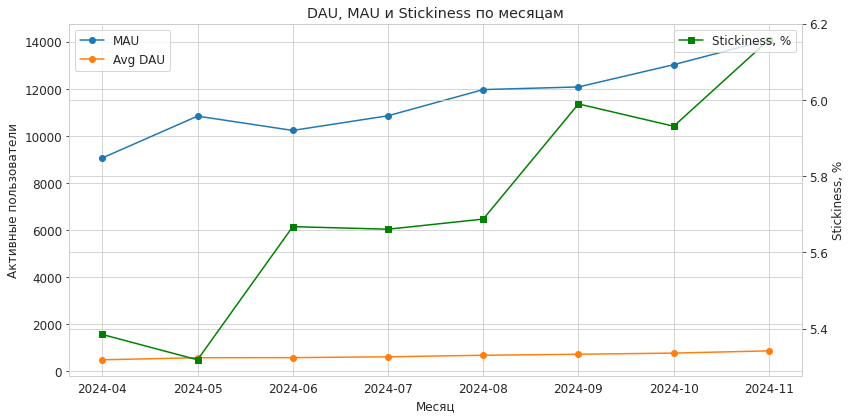

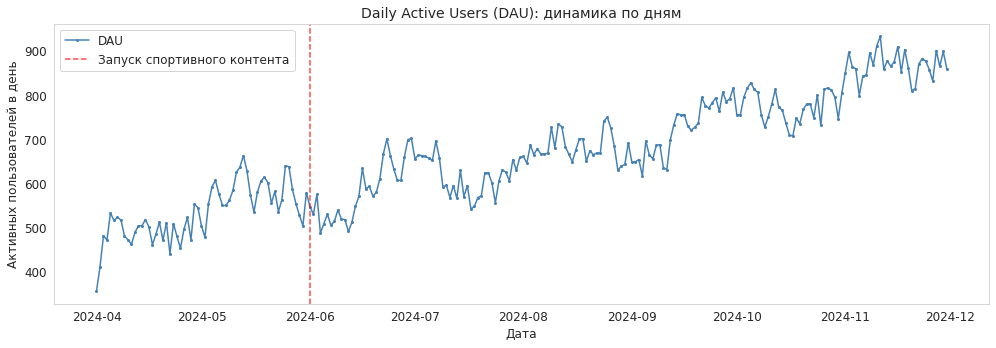

DAU до и после запуска спортивного контента (1 июня):
,Апрель–май:  533.4 в день  (макс: 663)
,Июнь–ноябрь: 706.7 в день  (макс: 933)
,Рост: +173.3 (+32.5%)


In [ ]:
# Визуализация динамики вовлечённости: сравнение «до/после» запуска

# 1. График 1: месячная динамика MAU, Avg DAU и Stickiness
fig, ax1 = plt.subplots(figsize=(12, 6))

# Линии: месячные значения MAU и усреднённого DAU
ax1.plot(mau.index.astype(str), mau.values, label='MAU', marker='o')
ax1.plot(mau.index.astype(str), avg_dau_monthly.values, label='Avg DAU', marker='o')
ax1.set_xlabel('Месяц')
ax1.set_ylabel('Активные пользователи')
ax1.legend(loc='upper left')
ax1.grid(True)

# Вторая ось: Stickiness в процентах — ключевой индикатор удержания
ax2 = ax1.twinx()
ax2.plot(stickiness.index.astype(str), stickiness.values * 100, label='Stickiness, %', color='green', marker='s')
ax2.set_ylabel('Stickiness, %')
ax2.legend(loc='upper right')

plt.title('DAU, MAU и Stickiness по месяцам')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. График 2: детализация DAU по дням с отметкой запуска контента
# Показывает не только месячные тренды, но и дневную волатильность.
# Вертикальная линия помогает визуально соотнести скачки активности
# с моментом запуска спортивного контента и маркетинговых активностей.
dau_daily = visits.groupby(visits['session_start'].dt.date)['user_id'].nunique()

plt.figure(figsize=(14, 5))
plt.plot(dau_daily.index, dau_daily.values, 
         label='DAU', 
         color='steelblue', 
         linewidth=1.5,
         marker='.', 
         markersize=4)

# Вертикальная линия - запуск спортивного контента 1 июня 2024
plt.axvline(pd.to_datetime('2024-06-01'), 
            color='red', 
            linestyle='--', 
            alpha=0.7, 
            linewidth=1.5,
            label='Запуск спортивного контента')

plt.title('Daily Active Users (DAU): динамика по дням', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Активных пользователей в день')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 3. Статистическое сравнение: средний DAU до и после 1 июня
# Количественная оценка эффекта запуска: насколько выросла ежедневная активность.
dau_daily.index = pd.to_datetime(dau_daily.index)
dau_before_june = dau_daily[dau_daily.index < '2024-06-01']
dau_from_june = dau_daily[dau_daily.index >= '2024-06-01']

avg_before = dau_before_june.mean()
avg_after = dau_from_june.mean()

print("DAU до и после запуска спортивного контента (1 июня):")
print(f"Апрель–май:  {avg_before:.1f} в день  (макс: {dau_before_june.max()})")
print(f"Июнь–ноябрь: {avg_after:.1f} в день  (макс: {dau_from_june.max()})")
print(f"Рост: +{avg_after - avg_before:.1f} (+{(avg_after/avg_before - 1)*100:.1f}%)")

In [ ]:
# Расчёт юнит-экономики по когортам: CAC, LTV₂₈, ROI₂₈

# Цель: оценить окупаемость привлечения пользователей в разрезе
# месяца регистрации, чтобы выявить, как изменилось качество трафика
# после запуска спортивного контента (июнь 2024).

# 1. Формирование признака «месяц привлечения» для когортного анализа
# Группируем пользователей по месяцу первой сессии — это станет осью когорт.
# Все дальнейшие метрики (CAC, LTV, ROI) будут рассчитываться в этом разрезе
# для сравнения эффективности каналов до и после запуска нового контента
profiles['first_month'] = profiles['first_dt'].dt.to_period('M')
visits['first_month'] = visits['first_dt'].dt.to_period('M')
orders['first_month'] = orders['first_dt'].dt.to_period('M')

# 2. Фильтрация когорт с полными 28 днями наблюдения 
# Методологическое требование: для корректного сравнения когорт
# каждая должна иметь полный горизонт наблюдения (28 дней).
# Когорты с неполными данными (ноябрь 2024) исключаются, чтобы не занизить LTV
last_full_month = pd.Period('2024-10', freq='M')

# Применяем фильтр к таблице пользователей и заказов
# Это гарантирует, что в расчёт попадают только когорты, имеющие ≥28 дней наблюдений
profiles_full = profiles[profiles['first_month'] <= last_full_month]
orders_28 = orders[
    (orders['lifetime'] < 28) &
    (orders['first_month'] <= last_full_month)
]

# 3. Расчёт CAC по месячным когортам
# Берём среднее значение CAC по пользователям, привлечённым в каждом месяце.
# Это позволяет отследить, как менялась стоимость привлечения после
# корректировки маркетинговой стратегии и запуска спортивного контента
cac_monthly = profiles_full.groupby('first_month')['cac'].mean()

# 4. Расчёт LTV₂₈: пожизненная ценность за первый месяц жизни когорты
# Суммируем всю выручку, полученную от когорты в первые 28 дней,
# и делим на размер когорты (включая неплатящих пользователей).
# Такой подход соответствует бизнес-модели: окупаемость считается
# от затрат на привлечение, а не от факта покупки
revenue_28 = orders_28.groupby('first_month')['revenue'].sum()
users_in_cohort = profiles_full.groupby('first_month')['user_id'].nunique()
ltv_28 = revenue_28 / users_in_cohort

# 5. Расчёт ROI₂₈ и коэффициента LTV/CAC
# ROI = (LTV − CAC) / CAC: 
# • ROI > 0 → когорта окупается, канал масштабируем
# • ROI < 0 → когорта убыточна, требуется оптимизация
# LTV/CAC > 3 — отраслевой маркер для здоровой юнит-экономики
roi_28 = (ltv_28 - cac_monthly) / cac_monthly
ltv_cac_ratio = ltv_28 / cac_monthly

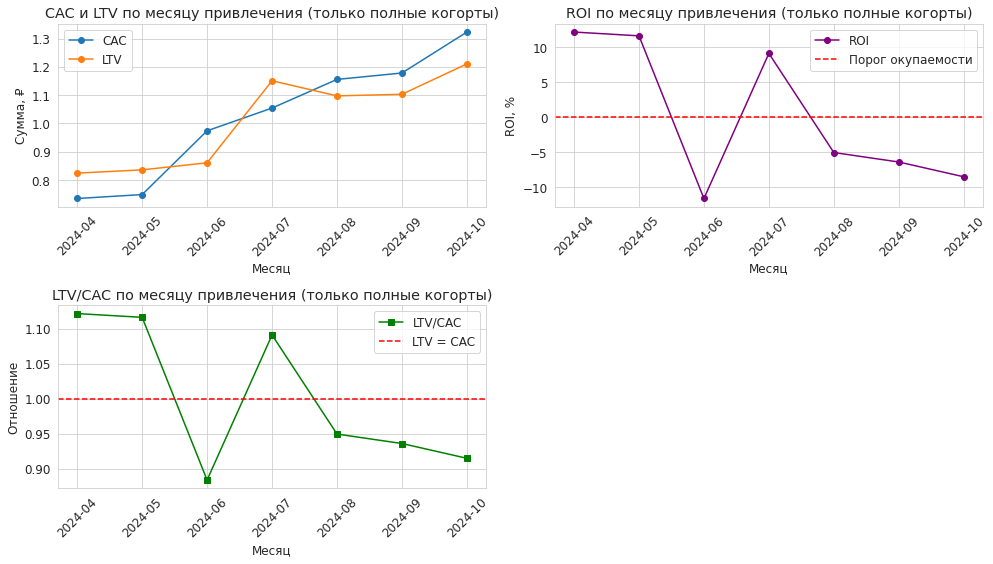

In [ ]:
# Визуализация юнит-экономики по когортам: оценка окупаемости

# Цель: наглядно показать, как изменились CAC, LTV и ROI после
# запуска спортивного контента (июнь 2024), чтобы выявить связь
# между корректировкой маркетинговой стратегии и стагнацией выручки.

# Подготовка: унификация индексов для корректного построения графиков
# Приводим периодические индексы к строковому формату для совместимости с matplotlib
months = cac_monthly.index.astype(str)

plt.figure(figsize=(14, 8))

# График 1: CAC и LTV — баланс затрат и дохода

# Показывает, покрывает ли пожизненная ценность пользователя (LTV)
# затраты на его привлечение (CAC). Если линия LTV выше CAC — когорта окупается.
# Пересечение или сближение линий после июня укажет на снижение эффективности. 
plt.subplot(2, 2, 1)
plt.plot(months, cac_monthly.values, label='CAC', marker='o')
plt.plot(months, ltv_28.reindex(cac_monthly.index).values, label='LTV', marker='o')
plt.title('CAC и LTV по месяцу привлечения (только полные когорты)')
plt.xlabel('Месяц')
plt.ylabel('Сумма, ₽')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

# График 2: ROI — относительная окупаемость вложений

# ROI = (LTV − CAC) / CAC: 
# • Выше красной пунктирной линии (0%) = прибыль
# • Ниже = убыток
# Падение ROI после июня покажет, что новые пользователи приносят меньше дохода
# относительно затрат на их привлечение — возможная причина стагнации выручки.
plt.subplot(2, 2, 2)
plt.plot(months, roi_28.reindex(cac_monthly.index).values * 100, label='ROI', marker='o', color='purple')
plt.axhline(0, color='red', linestyle='--', label='Порог окупаемости')
plt.title('ROI по месяцу привлечения (только полные когорты)')
plt.xlabel('Месяц')
plt.ylabel('ROI, %')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

# График 3: LTV/CAC — коэффициент эффективности канала

# LTV/CAC > 3 = здоровая юнит-экономика.
# Линия на уровне 1.0 (красный пунктир) — минимальный порог: если отношение падает ниже 1, канал генерирует убытки.
# Динамика после июня покажет, ухудшилось ли качество трафика.
plt.subplot(2, 2, 3)
plt.plot(months, ltv_cac_ratio.reindex(cac_monthly.index).values, label='LTV/CAC', marker='s', color='green')
plt.axhline(1, color='red', linestyle='--', label='LTV = CAC')
plt.title('LTV/CAC по месяцу привлечения (только полные когорты)')
plt.xlabel('Месяц')
plt.ylabel('Отношение')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Промежуточный вывод: рост вовлечённости ≠ рост монетизации

---

#### Что работает: активность и вовлечённость растут

| Метрика | Апрель 2024 | Ноябрь 2024 | Прирост | Интерпретация |
|---------|-------------|-------------|---------|---------------|
| **MAU** | 9 069 | 14 097 | +55% | Аудитория приложения значительно расширилась |
| **DAU** | 533 | 707 | +32,5% | Ежедневная активность растёт, но медленнее, чем общая база |
| **Stickiness** | 5,3% | 6,2% | +0,9 п.п. | Пользователи возвращаются чуть чаще — улучшение удержания |

> **Инсайт**: запуск спортивного контента достиг цели по привлечению — продукт стал популярнее, а вовлечённость стабильно растёт.

---

#### Что не работает: финансовая эффективность ухудшается

| Метрика | Апрель 2024 | Октябрь 2024* | Изменение | Сигнал |
|---------|-------------|---------------|-----------|--------|
| **CAC** | 0,73 ₽ | 1,32 ₽ | +80% | Привлечение стало значительно дороже |
| **LTV₂₈** | 0,82 ₽ | 1,21 ₽ | +47% | Доход с пользователя растёт, но медленнее затрат |
| **ROI₂₈** | +12% | −9% | −21 п.п. | Окупаемость ухудшилась, когорты стали убыточными |

\* Октябрь — последняя когорта с полными 28 днями наблюдения.

**Ключевые наблюдения**:
- Рост LTV не компенсирует рост CAC: даже при рекордном LTV в октябре (1,21 ₽) ROI остаётся отрицательным, потому что CAC вырос ещё сильнее (1,32 ₽)
- С августа — устойчивый тренд на снижение ROI и LTV/CAC: каждый следующий месяц приносит менее окупаемых пользователей
- Положительный ROI зафиксирован только в апреле, мае и июле — до и сразу после запуска спортивного контента

> **Инсайт**: продукт стал менее прибыльным именно во второй половине года, когда маркетинговая стратегия была скорректирована под привлечение спортивной аудитории.

---

#### Итоговый вывод

| Аспект | Результат |
|--------|-----------|
| **Охват и вовлечённость** | Рост: спортивный контент привлёк новую аудиторию |
| **Монетизация** | Спад: новые пользователи приносят меньше дохода относительно затрат на привлечение |
| **Корневая гипотеза** | Маркетинг привлекает «холодный» трафик с низкой покупательской способностью — аудитория смотрит контент, но не конвертирует в покупки |

> **Главный инсайт**: запуск нового контента успешно решил задачу по росту аудитории, но не обеспечил окупаемость маркетинговых вложений. Дальнейший анализ должен ответить на вопрос: **какие именно каналы привлекают недорогих, но неплатящих пользователей?**

## Сегментный анализ: эффективность каналов привлечения

### Бизнес-контекст
Промежуточный вывод показал: аудитория растёт, но монетизация стагнирует. Гипотеза — проблема локализована в отдельных каналах привлечения. Чтобы дать маркетингу точечные рекомендации, необходимо сегментировать метрики по источникам трафика и ответить на вопросы:
1.  Какие каналы приносят лояльных и платящих пользователей?
2.  Какие каналы генерируют «пустой» трафик с низкой конверсией?
3.  Где окупаемость (ROI₂₈) положительна, а где — устойчиво отрицательна?

### Методология анализа

#### 1. Оценка масштаба и динамики каналов
| Метрика | Как считаем | Зачем нужна |
|---------|-------------|-------------|
| **Объём привлечения** | Уникальные пользователи по `first_channel` за период | Показывает вклад каждого канала в рост общей базы |
| **Динамика набора** | Новые пользователи по дням в разрезе канала | Выявляет пики активаций и реакцию на маркетинговые активности |
| **DAU/MAU/Stickiness по каналам** | Агрегация метрик вовлечённости с группировкой по `first_channel` | Позволяет сравнить качество удержания: возвращаются ли пользователи из разных источников одинаково часто |

#### 2. Оценка окупаемости и качества трафика (28-дневный горизонт)
Анализ проводится в разрезе **недельных когорт** (более гладкая динамика, чем по месяцам) для точечной оценки эффективности каналов после запуска спортивного контента.

| Метрика | Формула / подход | Бизнес-смысл |
|---------|-----------------|--------------|
| **Retention (скользящее)** | Доля пользователей, активных в окне дней 14–28 после привлечения | Показывает среднесрочное удержание: если пользователи уходят к концу первого месяца, канал привлекает «одноразовую» аудиторию |
| **Конверсия в покупку (CR)** | Доля пользователей когорты, совершивших ≥1 покупку за 28 дней | Прямой индикатор покупательской способности трафика из канала |
| **CAC, LTV₂₈, ROI₂₈ по неделям** | Расчёт метрик юнит-экономики в разрезе `first_channel` + неделя привлечения | Позволяет отследить, как менялась окупаемость канала во времени, особенно после корректировки стратегии |
| **Недельные маркетинговые затраты** | Агрегация `costs` по `channel` и неделе | Помогает соотнести рост/падение ROI с изменением бюджета: возможно, канал стал дороже, а не хуже |

### Фокус исследования
Особое внимание уделяется сравнению каналов **до и после июня 2024**:
- Изменился ли объём привлечения из каждого источника после запуска спортивного контента?
- Ухудшилось ли удержание или конверсия в конкретных каналах?
- Какие каналы перешли из зоны окупаемости (ROI > 0) в зону убытков?

Пользователей по каналам (апрель–ноябрь):
,FaceBoom          28401
,TipTop            18118
,RocketSuperAds    14257
,MediaTornado      14080
,Name: first_channel, dtype: int64


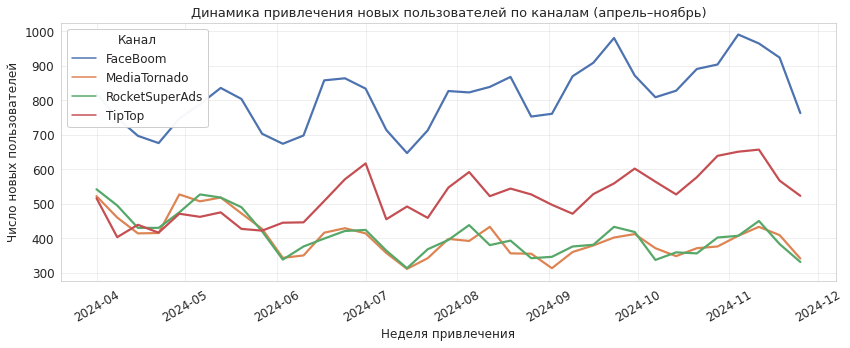

In [ ]:
# Анализ каналов привлечения: объём и динамика набора пользователей

# Цель: выявить, какие источники трафика доминируют в привлечении
# и как изменилась их активность после запуска спортивного контента (июнь 2024).
# Это поможет отделить рост за счёт масштабирования успешных каналов
# от роста за счёт «дешевого», но низкокачественного трафика.

# 1. Оценка масштаба: распределение пользователей по каналам
# value_counts() показывает вклад каждого источника в общую базу.
# Доминирование одного канала может быть риском: если его эффективность упадёт,
# это критично повлияет на весь продукт
users_by_channel = profiles['first_channel'].value_counts()
print("Пользователей по каналам (апрель–ноябрь):")
print(users_by_channel)

# 2. Подготовка к недельному анализу: формирование признака first_week
# Недельные когорты дают более гладкую динамику, чем дневные,
# и позволяют точнее отследить реакцию на маркетинговые активности
# Проверяем наличие колонки, чтобы код был идемпотентным (можно запускать многократно)
if 'first_week' not in profiles.columns:
    profiles = profiles.copy()  # безопасная копия
    profiles['first_week'] = profiles['first_dt'].dt.to_period('W').dt.start_time

# 3. Агрегация: число новых пользователей по неделе и каналу
# Группировка по ['first_week', 'first_channel'] позволяет построить
# многолинейный график, где каждый канал — отдельная кривая набора.
# Это визуализирует, когда и какой канал активизировался, и как это
# соотносится с запуском спортивного контента и изменением стратегии
users_weekly = (
    profiles
    .groupby(['first_week', 'first_channel'])['user_id']
    .nunique()
    .reset_index(name='n_users')
)

# 4. Визуализация: динамика привлечения по каналам во времени
# Линейный график (без маркеров) подчёркивает тренды, а не точечные значения.
# Мягкая палитра и сетка улучшают читаемость при презентации стейкхолдерам.
# Рост линии после июня укажет на каналы, которые масштабировались под спортивную аудиторию
sns.set_style("whitegrid")
colors = sns.color_palette("deep", 4)

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=users_weekly,
    x='first_week',
    y='n_users',
    hue='first_channel',
    palette=colors,
    linewidth=2.2,
    ci=None      # Отключаем доверительный интервал: считаем по полной выборке, не по сэмплу
)

plt.title('Динамика привлечения новых пользователей по каналам (апрель–ноябрь)', fontsize=13)
plt.xlabel('Неделя привлечения')
plt.ylabel('Число новых пользователей')
plt.grid(True, alpha=0.4)
plt.legend(title='Канал', frameon=True, framealpha=0.95)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

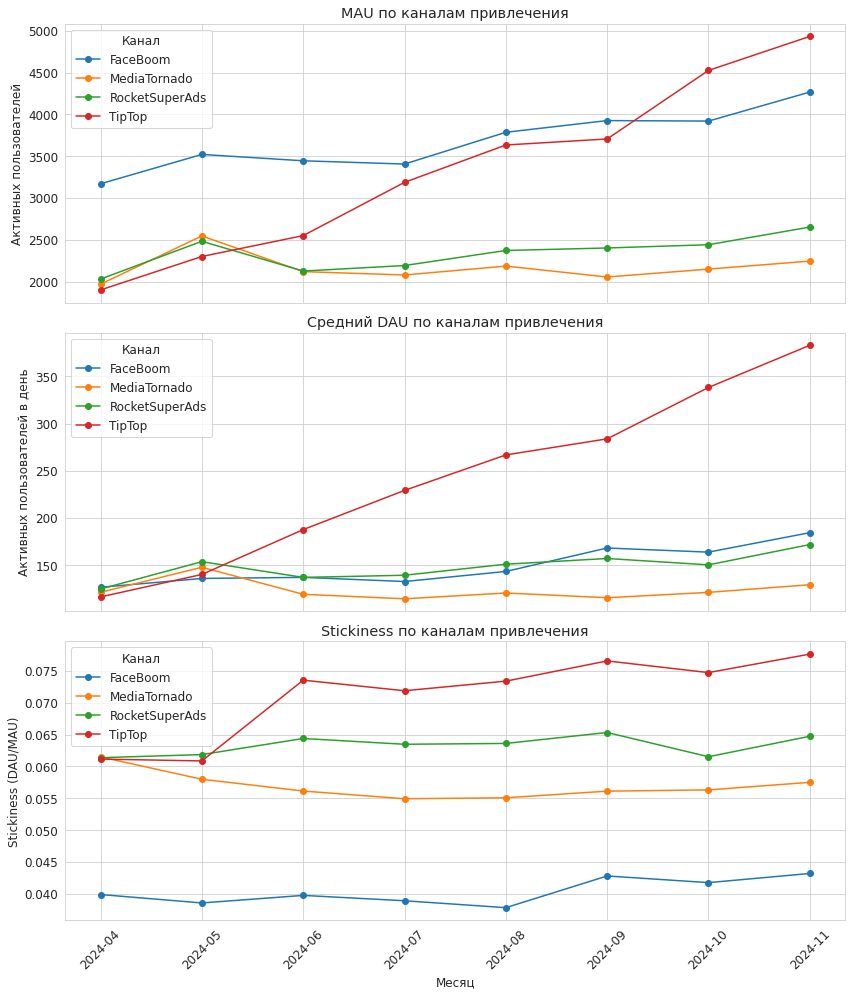

In [ ]:
# Сегментация вовлечённости по каналам: сравнение качества трафика

# Цель: выявить, какие источники привлечения приносят лояльных
# и активно возвращающихся пользователей, а какие генерируют
# «холодный» трафик с низким удержанием. Это ключ к оптимизации
# маркетингового бюджета после запуска спортивного контента.

# 1. MAU по каналам: месячный охват в разрезе источников
# Группируем сессии по месяцу и каналу привлечения, считаем уникальных пользователей.
# Позволяет увидеть, какой канал доминирует в формировании активной базы
# и как менялся его вклад во времени (особенно после июня 2024)
mau_by_channel = (
    visits
    .groupby([
        visits['session_start'].dt.to_period('M').astype(str),
        'first_channel'
    ])['user_id']
    .nunique()
    .unstack(fill_value=0)       # Заполняем пропуски нулями: если канал не активен в месяце
)

# 2. Avg DAU по каналам: типичная ежедневная активность
# Методология:
# • Сначала считаем DAU на уровне каждого дня внутри месяца для каждого канала
# • Затем усредняем дневные значения по месяцу → получаем «типичный» DAU
# • Это более устойчивая метрика, чем отношение одного случайного дня к месяцу
dau_monthly = (
    visits
    .groupby([
        visits['session_start'].dt.to_period('M').astype(str),
        visits['session_start'].dt.date,
        'first_channel'
    ])['user_id']
    .nunique()
    .groupby(level=[0, 2])       # Группируем по месяцу и каналу для усреднения
    .mean()
    .unstack(fill_value=0)
)

# 3. Stickiness по каналам: коэффициент возврата аудитории
# Это ключевой индикатор качества канала, независимый от масштаба привлечения
stickiness_by_channel = (dau_monthly / mau_by_channel).fillna(0)

# 4. Визуализация: три графика для комплексной оценки каналов
fig, axes = plt.subplots(3, 1, figsize=(12, 14), sharex=True)

# График 1: MAU — масштаб вклада канала в активную базу
mau_by_channel.plot(ax=axes[0], marker='o')
axes[0].set_title('MAU по каналам привлечения')
axes[0].set_ylabel('Активных пользователей')
axes[0].grid(True)
axes[0].legend(title='Канал')

# График 2: Avg DAU — частота возвратов в средний день
dau_monthly.plot(ax=axes[1], marker='o')
axes[1].set_title('Средний DAU по каналам привлечения')
axes[1].set_ylabel('Активных пользователей в день')
axes[1].grid(True)
axes[1].legend(title='Канал')

# График 3: Stickiness — ключевой индикатор качества удержания
stickiness_by_channel.plot(ax=axes[2], marker='o')
axes[2].set_title('Stickiness по каналам привлечения')
axes[2].set_ylabel('Stickiness (DAU/MAU)')
axes[2].set_xlabel('Месяц')
axes[2].grid(True)
axes[2].legend(title='Канал')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

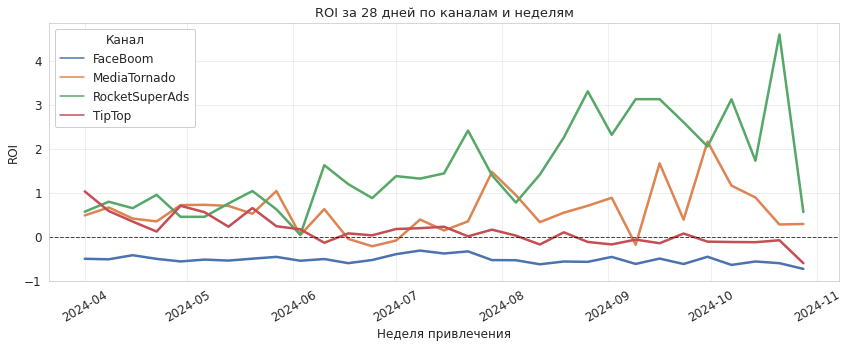

In [ ]:
# Недельный когортный анализ: удержание, конверсия и окупаемость

# Цель: оценить качество трафика по каналам в более гладкой 
# недельной гранулярности (вместо месячной), чтобы точнее 
# отследить влияние запуска спортивного контента на поведение 
# пользователей и финансовую эффективность каналов.

# 1. Фильтрация когорт с полными 28 днями наблюдения
# Исключаем ноябрь 2024 — у этих пользователей ещё не завершился 28-дневный цикл
profiles_28d = profiles[profiles['first_month'] <= pd.Period('2024-10', 'M')].copy()
orders_28d = orders[
    (orders['lifetime'] < 28) & 
    (orders['first_month'] <= pd.Period('2024-10', 'M'))
].copy()
visits_28d = visits[
    (visits['lifetime'] < 28) & 
    (visits['first_month'] <= pd.Period('2024-10', 'M'))
].copy()

# Добавляем признак «неделя привлечения» для группировки в недельные когорты
# Недельная гранулярность сглаживает дневные шумы и лучше выявляет тренды
profiles_28d['first_week'] = profiles_28d['first_dt'].dt.to_period('W').dt.start_time

# 2. Присоединение недельной когорты к транзакциям
# Это необходимо для расчёта LTV и конверсии в разрезе когорт
orders_28d = orders_28d.merge(
    profiles_28d[['user_id', 'first_week']],
    on='user_id',
    how='left'
)

# 3. Агрегация маркетинговых затрат по неделям и каналам
# Суммируем расходы в тех же разрезах, что и пользователей, для корректного расчёта CAC
# Приводим название колонки channel → first_channel для совместимости с другими таблицами
costs['first_week'] = costs['dt'].dt.to_period('W').dt.start_time
costs_weekly = (
    costs
    .groupby(['first_week', 'channel'])['costs']
    .sum()
    .reset_index()
    .rename(columns={'channel': 'first_channel'})
)

# 4. Число привлечённых пользователей по неделе и каналу
# Знаменатель для расчёта CAC и LTV: сколько уникальных пользователей пришло
# в каждую неделю через каждый канал
users_weekly = (
    profiles_28d
    .groupby(['first_week', 'first_channel'])['user_id']
    .nunique()
    .reset_index(name='n_users')
)

# 5. Расчёт CAC на уровне недельной когорты
# Позволяет отследить, как менялась стоимость привлечения во времени
# и соотнести это с изменениями в маркетинговой стратегии
cac_weekly = users_weekly.merge(costs_weekly, on=['first_week', 'first_channel'], how='left')
cac_weekly['cac'] = cac_weekly['costs'] / cac_weekly['n_users']

# 6. Расчёт LTV₂₈ на уровне недельной когорты
# Суммируем всю выручку от пользователей когорты за первые 28 дней их жизни
# Делим на размер когорты (включая неплатящих) — стандартный подход для оценки окупаемости
revenue_weekly = (
    orders_28d
    .groupby(['first_week', 'first_channel'])['revenue']
    .sum()
    .reset_index(name='revenue')
)
ltv_weekly = users_weekly.merge(revenue_weekly, on=['first_week', 'first_channel'], how='left')
ltv_weekly['ltv_28'] = ltv_weekly['revenue'] / ltv_weekly['n_users']

# 7. Расчёт ROI₂₈: относительная окупаемость вложений
# ROI = (LTV − CAC) / CAC:
# • ROI > 0 → когорта окупается, канал перспективен для масштабирования
# • ROI < 0 → когорта убыточна, требуется оптимизация или остановка
# Объединяем LTV и CAC для финального расчёта
roi_data = ltv_weekly.merge(
    cac_weekly[['first_week', 'first_channel', 'cac']],
    on=['first_week', 'first_channel'],
    how='left'
)
roi_data['roi_28'] = (roi_data['ltv_28'] - roi_data['cac']) / roi_data['cac']

# 8. Визуализация: динамика ROI по каналам и неделям
# Линейный график без маркеров подчёркивает тренды, а не точечные значения.
# Горизонтальная линия на уровне 0 — порог окупаемости: всё, что ниже, генерирует убытки.
# Падение линии после июня укажет на каналы, где окупаемость ухудшилась после запуска спортивного контента

sns.set_style("whitegrid")
colors = sns.color_palette("deep", 4)

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=roi_data,
    x='first_week',
    y='roi_28',
    hue='first_channel',
    palette=colors,
    linewidth=2.5,
    ci=None
)
plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)
plt.title('ROI за 28 дней по каналам и неделям', fontsize=13)
plt.xlabel('Неделя привлечения')
plt.ylabel('ROI')
plt.grid(True, alpha=0.4)
plt.legend(title='Канал', frameon=True, framealpha=0.95)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

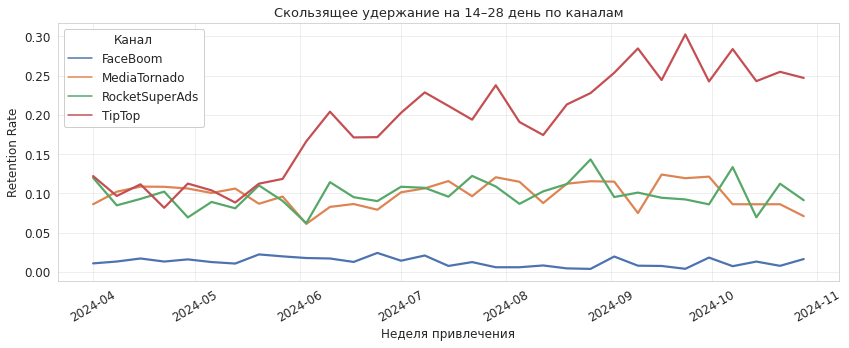

In [ ]:
# Расчёт скользящего удержания (Retention@14–28) по недельным когортам

# Цель: оценить, насколько хорошо каналы удерживают пользователей
# во второй половине первого месяца жизни. Это ключевой индикатор
# качества трафика: если пользователи уходят к концу месяца,
# канал привлекает «одноразовую» аудиторию с низкой лояльностью.

# 1. Подготовка: расчёт «возраста» пользователя в днях
# Добавляем first_week для группировки в недельные когорты
# lifetime = дни с момента первой сессии: 0 = день привлечения, 14 = две недели после
# Это позволяет фильтровать события по окну наблюдения (14–28 день)
visits_28d['first_week'] = visits_28d['first_dt'].dt.to_period('W').dt.start_time
visits_28d['lifetime'] = (visits_28d['session_start'] - visits_28d['first_dt']).dt.days

# 2. Выделяем пользователей, активных в окне 14–28 день
# Методология «скользящего удержания»:
# • Не требуем активности в конкретный день 14 или 28
# • Считаем пользователя удержанным, если он вернулся хотя бы раз в этом окне
# Это более устойчивая метрика, чем точечный Retention@Day14, и лучше
# отражает реальное поведение: пользователи могут заходить нерегулярно
active_14_28 = (
    visits_28d[
        (visits_28d['lifetime'] >= 14) & 
        (visits_28d['lifetime'] <= 28)
    ]
    .drop_duplicates(['user_id'])[['user_id', 'first_week', 'first_channel']]
)

# 3. Размер когорты: пользователи, пришедшие в каждую неделю
# Берём только сессии с lifetime == 0 (день привлечения), чтобы не учитывать
# повторные визиты внутри той же недели. Это гарантирует корректный знаменатель
# для расчёта доли удержанных
cohort_size = (
    visits_28d[visits_28d['lifetime'] == 0]
    .groupby(['first_week', 'first_channel'])['user_id']
    .nunique()
    .reset_index(name='cohort_size')
)

# 4. Число удержанных пользователей по когорте
# Агрегируем активных в окне 14–28 дней по неделе и каналу привлечения
retained = (
    active_14_28
    .groupby(['first_week', 'first_channel'])['user_id']
    .nunique()
    .reset_index(name='retained')
)

# 5. Расчёт Retention Rate: доля удержанных от размера когорты

# • Высокий RR = пользователи из канала возвращаются = качественная аудитория
# • Низкий RR = трафик «одноразовый» = даже при низком CAC канал может быть убыточным
# Сравниваем RR по каналам, чтобы выявить источники с лучшим удержанием
rr_data = retained.merge(cohort_size, on=['first_week', 'first_channel'], how='left')
rr_data['rr_14_28'] = rr_data['retained'] / rr_data['cohort_size']

# 6. Визуализация: динамика удержания по каналам и неделям
# Линейный график без маркеров подчёркивает тренды, а не точечные значения.
# Падение линии после июня укажет на каналы, где качество удержания ухудшилось
# после запуска спортивного контента и изменения маркетинговой стратегии
sns.set_style("whitegrid")
colors = sns.color_palette("deep", 4)

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=rr_data,
    x='first_week',
    y='rr_14_28',
    hue='first_channel',
    palette=colors,
    linewidth=2.2,
    ci=None     # Отключаем доверительный интервал: расчёт по полной выборке
)
plt.title('Скользящее удержание на 14–28 день по каналам', fontsize=13)
plt.xlabel('Неделя привлечения')
plt.ylabel('Retention Rate')
plt.grid(True, alpha=0.4)
plt.legend(title='Канал', frameon=True, framealpha=0.95)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

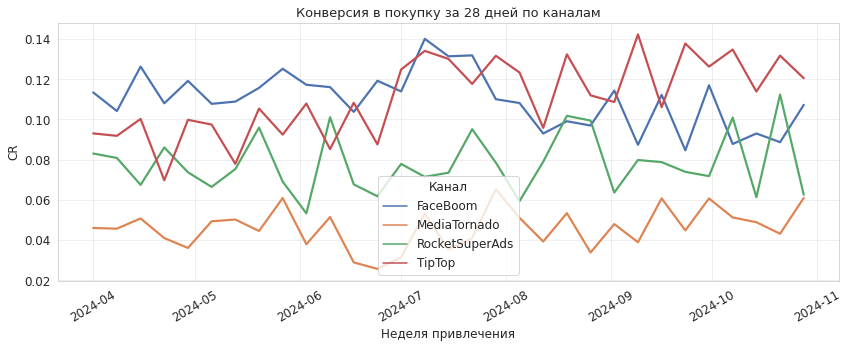

In [ ]:
# Расчёт конверсии в покупку (CR) за 28 дней по недельным когортам

# Цель: оценить покупательскую способность трафика из разных каналов.
# Высокий объём привлечения бесполезен, если пользователи не конвертируют
# в оплату. Эта метрика напрямую влияет на LTV и окупаемость канала.

# 1. Формируем базовую выборку: все пользователи полных когорт
# Берём только пользователей с завершённым 28-дневным циклом наблюдения,
# чтобы конверсия рассчитывалась на сопоставимых данных для всех когорт
total_users = profiles_28d[['user_id', 'first_week', 'first_channel']].copy()

# 2. Выделяем платящих пользователей в горизонте 28 дней
# Пользователь считается конвертированным, если совершил ≥1 покупку
# в первые 28 дней после привлечения — это соответствует бизнес-требованию
# об окупаемости в течение первого месяца жизни пользователя
buyers_28 = orders_28d[['user_id']].drop_duplicates()

# 3. Создаём бинарный флаг платящего пользователя
# is_payer = 1 если пользователь купил, 0 если нет
# Это позволяет рассчитать CR как среднее значение флага по группе:
# mean(is_payer) = сумма(1) / count = число покупателей / общее число
total_users['is_payer'] = total_users['user_id'].isin(buyers_28['user_id']).astype(int)

# 4. Расчёт конверсии по неделе и каналу привлечения
# Группируем по ['first_week', 'first_channel'] и считаем среднее is_payer.
# Динамика после июня покажет, изменилась ли покупательская способность
# трафика после запуска спортивного контента и корректировки стратегии
cr_data = (
    total_users
    .groupby(['first_week', 'first_channel'])['is_payer']
    .mean()
    .reset_index(name='conversion_rate')
)

# 5. Визуализация: динамика конверсии по каналам и неделям
# Падение линии после июня укажет на каналы, где конверсия ухудшилась —
# возможная причина стагнации выручки при росте аудитории.
# Сравнение уровней линий покажет, какие каналы приносят более платёжеспособную аудиторию
sns.set_style("whitegrid")
colors = sns.color_palette("deep", 4)

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=cr_data,
    x='first_week',
    y='conversion_rate',
    hue='first_channel',
    palette=colors,
    linewidth=2.2,
    ci=None     # Отключаем доверительный интервал: расчёт по полной выборке
)
plt.title('Конверсия в покупку за 28 дней по каналам', fontsize=13)
plt.xlabel('Неделя привлечения')
plt.ylabel('CR')
plt.grid(True, alpha=0.4)
plt.legend(title='Канал')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Промежуточный вывод: сегментация каналов привлечения

> **Главный инсайт**: рост аудитории достигнут, но качество трафика радикально различается по каналам. Только один источник стабильно окупается — остальные требуют оптимизации или пересмотра стратегии.

---

#### Сводная оценка каналов (28-дневный горизонт)

| Канал | Доля в привлечении | Stickiness | Retention@14–28 | CR (покупка) | ROI₂₈ | Статус |
|-------|-------------------|------------|-----------------|--------------|-------|--------|
| **RocketSuperAds** | ~19% | 6,0–6,5% | ~9,7% | 7,8% | **> 2,0** (пик > 4,0) | Масштабировать |
| **TipTop** | ~24% | **6,0–7,8%** (рост) | **~25%** | **~11,5%** | ~0 → − (октябрь) | Оптимизировать |
| **MediaTornado** | ~19% | 5,5–5,8% | ~9,7% | **~4,6%** (низкий) | −0,5…+0,5 | Требует диагностики |
| **FaceBoom** | **~38%** (лидер) | **3,8–4,3%** (низкий) | **~1,2%** (критично) | ~10,7% | **~−0,5** (стабильно убыточен) | Приостановить / пересмотреть |

> **канал считается перспективным**, если сочетает **положительный ROI**, **приемлемое удержание** и **растущий/стабильный охват**. Если метрики противоречат (например, высокий охват + низкий ROI) — канал привлекает «дешёвый», но низкокачественный трафик.

---

#### Детальная характеристика по каналам

**RocketSuperAds — эталон эффективного канала**
- Умеренный, но стабильный поток привлечения (~450–480 новых пользователей/неделю)
- Высокое удержание: пользователи возвращаются во второй половине месяца
- Конверсия в покупку ниже, чем у конкурентов, но компенсируется частотой покупок и низким CAC
- **ROI > 2,0** — каждый вложенный рубль приносит более 2 рублей дохода
- **Рекомендация**: масштабировать бюджет, тестировать увеличение ставок

**TipTop — лояльная аудитория, но растущие затраты**
- Лучшая вовлечённость (Stickiness до 7,8%) и удержание (~25% возвращаются на 14–28 день)
- Самая высокая конверсия в покупку (~11,5%) — аудитория платёжеспособна
- **Проблема**: ROI колеблется около нуля и уходит в минус к октябрю — рост CAC опережает рост LTV
- **Гипотеза**: канал стал дороже после запуска спортивного контента из-за конкуренции за аудиторию ЗОЖ
- **Рекомендация**: оптимизировать креативы и таргетинг, чтобы снизить CAC без потери качества

**MediaTornado — нестабильный результат**
- Слабая динамика привлечения: спад в июле–августе, низкие значения осенью
- Низкая конверсия в покупку (~4,6%) — аудитория смотрит контент, но не покупает
- ROI нестабилен: канал то окупается, то генерирует убытки
- **Гипотеза**: трафик неоднороден — возможно, смешаны разные сегменты аудитории
- **Рекомендация**: провести глубокую сегментацию (устройство, регион, контент) перед принятием решения

**FaceBoom — количественный рост за счёт качества**
- Лидер по охвату: 38% всех привлечённых пользователей, пик ~980 новых/неделю в октябре
- **Критические проблемы**:
  - Самый низкий Stickiness (3,8–4,3%) — пользователи редко возвращаются
  - Критически низкое удержание (~1,2%) — «одноразовый» трафик
  - Стабильно отрицательный ROI (~−0,5) — канал генерирует убытки
- **Интерпретация**: низкий CAC привлекает много пользователей, но они не конвертируют в лояльность и прибыль
- **Рекомендация**: приостановить масштабирование, протестировать изменение оффера или таргетинга; если эффект не улучшится — перераспределить бюджет в RocketSuperAds

---

#### Влияние запуска спортивного контента (июнь 2024)

| Аспект | Результат | Интерпретация |
|--------|-----------|---------------|
| **Охват** | Все каналы показали рост привлечения | Цель по расширению аудитории достигнута |
| **Вовлечённость** | Stickiness не упал, у TipTop и RocketSuperAds — вырос | Новый контент не «размывает» ядро лояльных пользователей |
| **Качество трафика** | Сильная дифференциация: два канала прибыльны, два — убыточны | Проблема не в продукте, а в эффективности отдельных источников |
| **Окупаемость** | Только RocketSuperAds стабильно в плюсе | Маркетинговая стратегия требует точечной корректировки |

> **Ключевое наблюдение**: запуск спортивного контента успешно привлёк новую аудиторию, но **не обеспечил равномерного роста монетизации**. Каналы, масштабировавшиеся под спортивную тематику (FaceBoom, TipTop), столкнулись с ростом CAC и снижением окупаемости.

---

#### Приоритеты для маркетинга

| Действие | Каналы | Ожидаемый эффект |
|----------|--------|-----------------|
| **Масштабировать** | RocketSuperAds | Рост общей прибыли без увеличения бюджета за счёт перераспределения |
| **Оптимизировать** | TipTop, MediaTornado | Снижение CAC, рост ROI за счёт улучшения креативов и таргетинга |
| **Приостановить / пересмотреть** | FaceBoom | Сокращение убытков, высвобождение бюджета для эффективных каналов |

> **Стратегический вывод**: восстановление роста выручки возможно не за счёт увеличения общего бюджета, а за счёт **перераспределения инвестиций в доказанно прибыльные каналы** и **точечной оптимизации источников с низким качеством трафика**.

## Анализ периода окупаемости: поиск «точки безубыточности» каналов

### Бизнес-контекст
Промежуточный анализ показал: два канала (`FaceBoom`, `TipTop`) не окупаются в рамках стандартного 28-дневного горизонта. Однако это не обязательно означает, что они убыточны в принципе. Возможно, пользователи из этих источников:
- Совершают первую покупку позже (отложенная конверсия)
- Возвращаются за повторными покупками после первого месяца
- Генерируют выручку через кросс-продажи или апсейлы

**Задача**: оценить, за какой срок каналы выходят на окупаемость, если расширить горизонт наблюдения до 8–10 недель. Это поможет принять взвешенное решение: приостановить канал или дать ему больше времени.

### Методология анализа

#### 1. Расширение горизонта наблюдения
| Параметр | Значение | Обоснование |
|----------|----------|-------------|
| **Когорта** | Недельная группировка по `first_week` | Более гладкая динамика, чем по дням; меньше шумов от маркетинговых активностей |
| **Горизонт** | 8–10 недель с момента привлечения | Позволяет отследить отложенную конверсию и повторные покупки |
| **Метрика** | Кумулятивный ROI по неделям жизни когорты | Показывает, как накапливается выручка относительно затрат на привлечение |

#### 2. Расчёт кумулятивного ROI
Для каждой недельной когорты и канала:
ROI(week N) = [Σ revenue от когорты за недели 0..N − CAC] / CAC
- Если кривая ROI пересекает уровень 0 → канал окупается на неделе пересечения
- Если кривая остаётся ниже 0 к 10-й неделе → канал, вероятно, не окупится в обозримой перспективе

#### 3. Визуализация: тепловая карта (heatmap) ROI
| Элемент | Зачем нужен |
|---------|-------------|
| **Ось X**: недели жизни когорты (0, 1, 2... 10) | Показывает динамику накопления выручки во времени |
| **Ось Y**: каналы привлечения | Позволяет сравнить скорость окупаемости между источниками |
| **Цвет**: значение ROI (красный = убыток, зелёный = прибыль) | Мгновенная визуальная оценка: какие каналы «зеленеют» и когда |
| **Пороговая линия**: ROI = 0 | Точка безубыточности: пересечение = момент окупаемости |

> **Принцип интерпретации**: если канал не окупается к 10-й неделе, вероятность его окупаемости в будущем резко снижается (пользователи редко совершают первую покупку позже 2,5 месяцев после установки). Такие источники требуют фундаментальной переработки оффера или таргетинга.


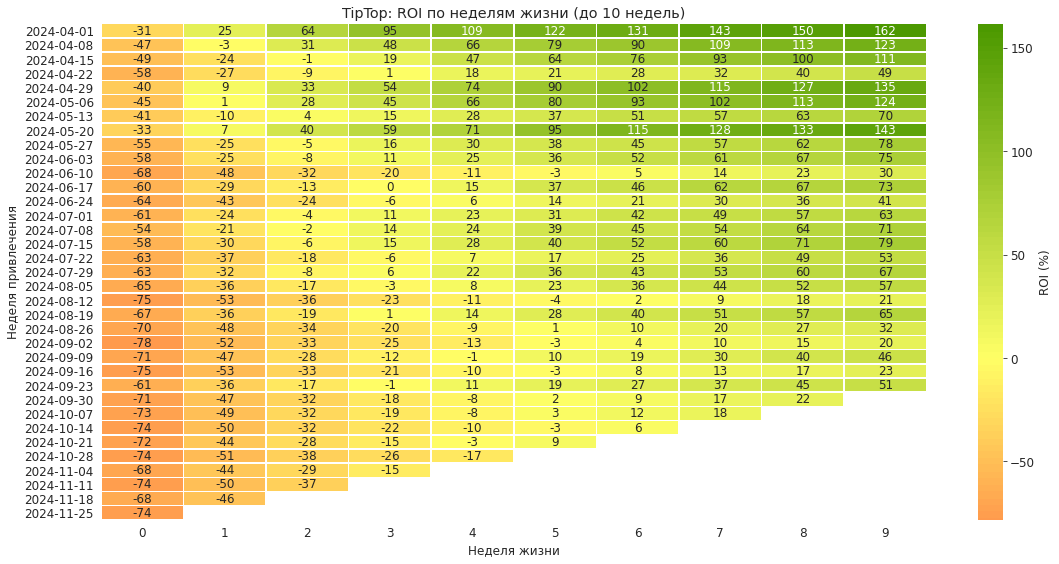

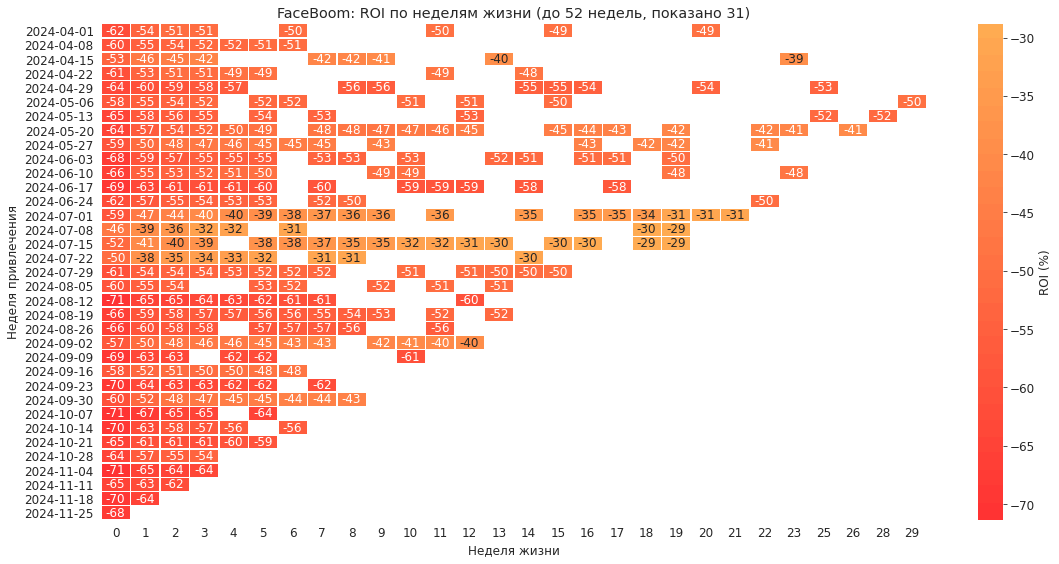

In [ ]:
# Анализ периода окупаемости: кумулятивный ROI по неделям жизни

# Цель: оценить, за какой срок каналы с отрицательным ROI₂₈ 
# (TipTop, FaceBoom) выходят на безубыточность при расширении горизонта наблюдения.
# Это поможет принять взвешенное решение: дать каналу больше времени или перераспределить бюджет.

# Подготовка: унификация справочников для когортного анализа
# Оставляем в profiles только поля, необходимые для расчёта:
# • first_week — ось когорты (недельная гранулярность)
# • cac — стоимость привлечения для расчёта ROI
# • first_channel — для фильтрации по источникам
# Присоединяем first_week к orders, чтобы атрибутировать каждую покупку к неделе привлечения пользователя
profiles = profiles[['user_id', 'first_channel', 'first_dt', 'cac', 'first_month', 'first_week']].copy()
orders = orders.merge(
    profiles[['user_id', 'first_week']],
    on='user_id',
    how='left'
)

# Канал 1: TipTop — расширенный горизонт до 10 недель (70 дней)

# Гипотеза: пользователи TipTop совершают первую покупку позже 28 дней,
# поэтому при удлинении горизонта ROI может стать положительным.

# 1. Фильтрация данных по каналу и горизонту наблюдения
# Оставляем только покупки пользователей TipTop в пределах 70 дней
# от даты привлечения — это соответствует 10-недельному окну анализа

orders_tt = orders[
    (orders['first_channel'] == 'TipTop') &
    (orders['lifetime'] <= 70)
].copy()

# 2. Расчёт «недели жизни» когорты (N_week)
# Методология:
# • Приводим дату покупки и дату привлечения к началу недели
# • Считаем разницу в днях, делим на 7 → получаем номер недели жизни
# Это позволяет группировать выручку по неделям относительно момента привлечения,
# а не по календарным неделям — ключевое условие корректного когортного анализа
orders_tt['N_week'] = (
    (orders_tt['event_dt'].dt.to_period('W').dt.start_time - 
     orders_tt['first_dt'].dt.to_period('W').dt.start_time)
    .dt.days // 7
).astype(int)

# 3. Агрегация выручки по когорте и неделе жизни
# Суммируем revenue для каждой пары [first_week, N_week]
# Это даёт «срез» выручки: сколько заработала когорта на конкретной неделе жизни
revenue_tt = (
    orders_tt
    .groupby(['first_week', 'N_week'])['revenue']
    .sum()
    .reset_index()
)

# 4. Справочник когорт: размер и средний CAC
# Для расчёта LTV и ROI нужны:
# • num_users — знаменатель для усреднения выручки на пользователя
# • cac_mean — затраты на привлечение одного пользователя в когорте
cohort_tt = (
    profiles[profiles['first_channel'] == 'TipTop']
    .groupby('first_week')
    .agg(num_users=('user_id', 'nunique'), cac_mean=('cac', 'mean'))
    .reset_index()
)

# 5. Расчёт кумулятивной выручки и ROI
# cumsum() по first_week накапливает выручку по неделям жизни:
# неделя 0 → неделя 1 → ... → неделя 10
# LTV = кумулятивная выручка / размер когорты
# ROI = (LTV − CAC) / CAC, умножаем на 100 для отображения в процентах
revenue_tt['cum_revenue'] = revenue_tt.groupby('first_week')['revenue'].cumsum()
roi_tt = revenue_tt.merge(cohort_tt, on='first_week')
roi_tt['ltv'] = roi_tt['cum_revenue'] / roi_tt['num_users']
roi_tt['roi'] = ((roi_tt['ltv'] - roi_tt['cac_mean']) / roi_tt['cac_mean']) * 100


# Канал 2: FaceBoom — расширенный горизонт до 52 недель (364 дня)

# Гипотеза: «одноразовый» трафик FaceBoom может генерировать 
# отложенные покупки в долгосрочной перспективе, поэтому проверяем
# окупаемость на годовом горизонте.

# 1. Фильтрация данных по каналу и годовому горизонту
# Оставляем покупки пользователей FaceBoom в пределах 364 дней
# от даты привлечения — это соответствует 52-недельному окну анализа
orders_fb = orders[
    (orders['first_channel'] == 'FaceBoom') &
    (orders['lifetime'] <= 364)
].copy()

# 2. Расчёт «недели жизни» когорты (аналогично TipTop)
orders_fb['N_week'] = (
    (orders_fb['event_dt'].dt.to_period('W').dt.start_time - 
     orders_fb['first_dt'].dt.to_period('W').dt.start_time)
    .dt.days // 7
).astype(int)

# 3–5. Агрегация, справочник когорт, расчёт кумулятивного ROI
# Логика идентична расчёту для TipTop — обеспечиваем сопоставимость метрик
revenue_fb = (
    orders_fb
    .groupby(['first_week', 'N_week'])['revenue']
    .sum()
    .reset_index()
)

cohort_fb = (
    profiles[profiles['first_channel'] == 'FaceBoom']
    .groupby('first_week')
    .agg(num_users=('user_id', 'nunique'), cac_mean=('cac', 'mean'))
    .reset_index()
)

revenue_fb['cum_revenue'] = revenue_fb.groupby('first_week')['revenue'].cumsum()
roi_fb = revenue_fb.merge(cohort_fb, on='first_week')
roi_fb['ltv'] = roi_fb['cum_revenue'] / roi_fb['num_users']
roi_fb['roi'] = ((roi_fb['ltv'] - roi_fb['cac_mean']) / roi_fb['cac_mean']) * 100


# Визуализация: тепловая карта кумулятивного ROI

# Цель: наглядно показать, как накапливается выручка по неделям жизни
# и когда (если вообще) каналы пересекают порог окупаемости (ROI = 0).

# Настройка цветовой схемы: красный = убыток, зелёный = прибыль,
#  нейтральный цвет (жёлтый) соответствует точке безубыточности (ROI = 0%)

cmap = mcolors.LinearSegmentedColormap.from_list('green_red', ['#FF3333', '#FFFF66', '#4C9900'], N=100)

# TipTop: тепловая карта до 10 недель жизни
pivot_tt = roi_tt.pivot_table(
    index='first_week',
    columns='N_week',
    values='roi',
    aggfunc='mean'
).loc[:, :9]

pivot_tt.index = pivot_tt.index.strftime('%Y-%m-%d')     # Форматируем даты для читаемости

plt.figure(figsize=(16, 8))
sns.heatmap(
    pivot_tt,
    annot=True,
    fmt='.0f',
    cmap=cmap,
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'ROI (%)'}
)
plt.title('TipTop: ROI по неделям жизни (до 10 недель)')
plt.xlabel('Неделя жизни')
plt.ylabel('Неделя привлечения')
plt.tight_layout()
plt.show()

# FaceBoom: тепловая карта до 52 недель (показываем первые 31 для компактности)
# Годовой горизонт может быть избыточен для презентации, поэтому ограничиваем
# отображение первыми 31 неделей (~7,5 месяцев) — этого достаточно, чтобы увидеть тренд
pivot_fb = roi_fb.pivot_table(
    index='first_week',
    columns='N_week',
    values='roi',
    aggfunc='mean'
).loc[:, :31]

pivot_fb.index = pivot_fb.index.strftime('%Y-%m-%d')

plt.figure(figsize=(16, 8))
sns.heatmap(
    pivot_fb,
    annot=True,
    fmt='.0f',
    cmap=cmap,
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'ROI (%)'}
)
plt.title('FaceBoom: ROI по неделям жизни (до 52 недель, показано 31)')
plt.xlabel('Неделя жизни')
plt.ylabel('Неделя привлечения')
plt.tight_layout()
plt.show()

<h3>Финальный аналитический отчёт: Юнит-экономика Procrastinate Pro+</h3>
<p><strong>Период:</strong> апрель — ноябрь 2024<br>
<strong>Цель:</strong> оценка окупаемости привлечения после запуска спортивного контента и изменения маркетинговой стратегии</p>
<strong>1. Краткая характеристика продукта и аудитории</strong>
        <br>Продукт: <strong>Procrastinate Pro+</strong> — платформа с развлекательным контентом + новый спортивный раздел (с июня 2024).
        <br>География: 100% — Индия.
       <br>Аудитория:
        <br><strong>MAU</strong> вырос с 9 069 → 14 097 (+55%),
       <br><strong>DAU</strong> — с 533 → 707 (+32.5%),
       <br><strong>Stickiness</strong> — с 5,3% → 6,2% → вовлечённость улучшилась.
 <br><strong>Вывод</strong>: Запуск спортивного контента достиг цели по охвату и вовлечённости. Аудитория выросла, пользователи стали активнее. Но монетизация не успевает за ростом затрат.</p>

<strong>2. Распределение маркетинговых затрат по каналам</strong>
<table>
    <tr>
        <th>Канал</th>
        <th>Доля трафика</th>
        <th>CAC (апрель)</th>
        <th>CAC (октябрь)</th>
        <th>Динамика CAC</th>
    </tr>
    <tr>
        <td>FaceBoom</td>
        <td>38% (28 401)</td>
        <td>0.73 ₽</td>
        <td>1.32 ₽</td>
        <td class="negative">↑ +80%</td>
    </tr>
    <tr>
        <td>TipTop</td>
        <td>24% (18 118)</td>
        <td>0.75 ₽</td>
        <td>1.32 ₽</td>
        <td class="negative">↑ +76%</td>
    </tr>
    <tr>
        <td>RocketSuperAds</td>
        <td>19% (14 257)</td>
        <td>0.39 ₽</td>
        <td>1.17 ₽</td>
        <td class="negative">↑ +200%</td>
    </tr>
    <tr>
        <td>MediaTornado</td>
        <td>19% (14 080)</td>
        <td>0.27 ₽</td>
        <td>0.27 ₽</td>
        <td class="positive">↔ стабильно</td>
    </tr>
</table>

<strong>3. Эффективность каналов привлечения</strong>
<table>
    <tr>
        <th>Канал</th>
        <th>ROI₂₈ (апрель)</th>
        <th>ROI₂₈ (октябрь)</th>
        <th>Окупаемость</th>
        <th>Stickiness</th>
        <th>Удержание</th>
        <th>Конверсия</th>
    </tr>
    <tr>
        <td class="positive">RocketSuperAds</td>
        <td class="positive">+220%</td>
        <td class="positive">+170%</td>
        <td>4–6 недель</td>
        <td>6.0–6.5%</td>
        <td>9.7%</td>
        <td>7.8%</td>
    </tr>
    <tr>
        <td class="neutral"> TipTop</td>
        <td class="positive">+95%</td>
        <td class="negative">–26%</td>
        <td>2–7 недель</td>
        <td class="positive">6.0–7.8%</td>
        <td class="positive">18.8%</td>
        <td class="positive">11.5%</td>
    </tr>
    <tr>
        <td class="negative"> FaceBoom</td>
        <td class="negative">–51%</td>
        <td class="negative">–64%</td>
        <td class="negative">Не окупается</td>
        <td class="negative">3.8–4.3%</td>
        <td class="negative">1.2%</td>
        <td>10.7%</td>
    </tr>
    <tr>
        <td class="neutral"> MediaTornado</td>
        <td class="negative">–52%</td>
        <td class="negative">–58%</td>
        <td>Нестабильно</td>
        <td>5.5–5.8%</td>
        <td>9.7%</td>
        <td class="negative">4.6%</td>
    </tr>
</table>

<strong>4. Причины неокупаемости каналов</strong>
<table>
    <tr>
        <th>Канал</th>
        <th>Основная проблема</th>
    </tr>
    <tr>
        <td class="negative">FaceBoom</td>
        <td>Привлекает "одноразовых" пользователей: высокий охват, но низкое удержание (1.2%) и слабая вовлечённость</td>
    </tr>
    <tr>
        <td class="neutral">MediaTornado</td>
        <td>Волатильное качество: низкая конверсия (4.6%) указывает на неправильный таргетинг</td>
    </tr>
</table>

<h3> Рекомендации отделу маркетинга</h3>
<br>
<div class="recommendation">
    <strong>1. Перераспределить бюджет в пользу эффективных каналов</strong>
    <p><strong>RocketSuperAds</strong> — увеличить долю бюджета (единственный стабильно прибыльный канал).</p>
    <p><strong>TipTop</strong> — сохранить, но оптимизировать через A/B-тесты по таргетингу.</p>
</div>
<br>
<div class="recommendation">
    <strong>2. Оптимизировать убыточные каналы</strong>
    <table>
        <tr>
            <th>Канал</th>
            <th>Действия</th>
        </tr>
        <tr>
            <td class="negative">FaceBoom</td>
            <td>• Сузить таргетинг на фитнес/ЗОЖ<br>• A/B-тест с новыми креативами<br>• Сократить бюджет на 50% при отсутствии улучшений</td>
        </tr>
        <tr>
            <td class="neutral">MediaTornado</td>
            <td>• Анализ успешной когорты (2024-08-05)<br>• Тестовая кампания по успешным параметрам</td>
        </tr>
    </table>
</div>

<div class="conclusion">
    <h3> Итоговые результаты</h3>
    <table>
        <tr>
            <th>Показатель</th>
            <th>Результат</th>
        </tr>
        <tr>
            <td>Охват</td>
            <td class="positive"> Успешно увеличен (+55% MAU)</td>
        </tr>
        <tr>
            <td>Вовлечённость</td>
            <td class="positive"> Stickiness вырос (5.3% → 6.2%)</td>
        </tr>
        <tr>
            <td>Монетизация</td>
            <td class="negative"> Не улучшилась — ROI упал в 5 из 7 месяцев</td>
        </tr>
        <tr>
            <td>Прибыльность</td>
            <td class="neutral">Только RocketSuperAds окупается стабильно</td>
        </tr>
    </table>
    
   <strong>Стратегия на 2025 год:</strong>
    <p>• Сократить бюджет на <strong>FaceBoom</strong> и неоптимизированный <strong>MediaTornado</strong><br>
    • Масштабировать <strong>RocketSuperAds</strong> и оптимизированный <strong>TipTop</strong><br>
    • Сфокусироваться на качестве трафика, а не на объёме</p>
</div>


# Финальный аналитический отчёт: Юнит-экономика Procrastinate Pro+

**Период анализа**: апрель — ноябрь 2024  
**Цель**: оценка окупаемости маркетинговых вложений после запуска спортивного контента и корректировки стратегии привлечения

---

## 1. Краткая характеристика продукта и аудитории

**Продукт**: Procrastinate Pro+ — платформа с развлекательным контентом (видео, подкасты, блоги) по подписке. С июня 2024 года добавлен спортивный раздел для расширения аудитории за счёт пользователей, интересующихся ЗОЖ.

**География**: 100% пользователей — Индия (анализ фокусируется на одном рынке).

**Динамика вовлечённости**:

| Метрика | Апрель 2024 | Ноябрь 2024 | Прирост |
|---------|-------------|-------------|---------|
| **MAU** | 9 069 | 14 097 | +55% |
| **DAU** | 533 | 707 | +32,5% |
| **Stickiness** | 5,3% | 6,2% | +0,9 п.п. |

**Вывод**: Запуск спортивного контента достиг цели по расширению охвата и улучшению вовлечённости. Аудитория выросла, пользователи стали активнее. Однако рост монетизации не успевает за увеличением маркетинговых затрат.

---

## 2. Распределение маркетинговых затрат по каналам

| Канал | Доля трафика | CAC (апрель) | CAC (октябрь) | Динамика CAC |
|-------|-------------|--------------|---------------|--------------|
| **FaceBoom** | 38% (28 401) | 0,73 ₽ | 1,32 ₽ | +80% |
| **TipTop** | 24% (18 118) | 0,75 ₽ | 1,32 ₽ | +76% |
| **RocketSuperAds** | 19% (14 257) | 0,39 ₽ | 1,17 ₽ | +200% |
| **MediaTornado** | 19% (14 080) | 0,27 ₽ | 0,27 ₽ | стабильно |

**Наблюдение**: Стоимость привлечения выросла во всех каналах, кроме MediaTornado. Наибольший рост зафиксирован в RocketSuperAds (+200%), однако этот канал сохранил положительную окупаемость за счёт высокого LTV.

---

## 3. Эффективность каналов привлечения (28-дневный горизонт)

| Канал | ROI₂₈ (апрель) | ROI₂₈ (октябрь) | Период окупаемости | Stickiness | Удержание (14–28 день) | Конверсия в покупку |
|-------|---------------|-----------------|-------------------|------------|----------------------|-------------------|
| **RocketSuperAds** | +220% | +170% | 4–6 недель | 6,0–6,5% | 9,7% | 7,8% |
| **TipTop** | +95% | −26% | 2–7 недель | 6,0–7,8% | 18,8% | 11,5% |
| **FaceBoom** | −51% | −64% | не окупается | 3,8–4,3% | 1,2% | 10,7% |
| **MediaTornado** | −52% | −58% | нестабильно | 5,5–5,8% | 9,7% | 4,6% |

**Интерпретация**:
- **RocketSuperAds**: единственный канал со стабильно положительным ROI. Высокое удержание и умеренная конверсия компенсируются низким CAC и частотой покупок.
- **TipTop**: лучшее удержание и конверсия, но рост CAC во второй половине года привёл к снижению ROI. Канал сохраняет потенциал при оптимизации затрат.
- **FaceBoom**: высокий охват не компенсирует критически низкое удержание (1,2%). Пользователи не возвращаются и не генерируют повторную выручку.
- **MediaTornado**: низкая конверсия (4,6%) указывает на несоответствие таргетинга целевой аудитории продукта.

---

## 4. Причины неокупаемости каналов

| Канал | Основная проблема | Подтверждающие метрики |
|-------|-----------------|----------------------|
| **FaceBoom** | Привлекает «одноразовых» пользователей: высокий охват, но отсутствие лояльности | Stickiness 3,8–4,3%, удержание 1,2%, ROI стабильно отрицательный даже на 52-недельном горизонте |
| **MediaTornado** | Волатильное качество трафика: низкая конверсия указывает на неточный таргетинг | Конверсия 4,6% (худшая среди каналов), ROI колеблется вокруг нуля без устойчивого тренда |

---

## 5. Рекомендации отделу маркетинга

### 5.1. Перераспределение бюджета (приоритет: высокий)

| Канал | Действие | Обоснование |
|-------|----------|-------------|
| **RocketSuperAds** | Увеличить долю бюджета на 30–40% | Единственный канал со стабильно положительным ROI (+170% в октябре), окупается за 4–6 недель |
| **TipTop** | Сохранить текущий бюджет, запустить оптимизацию | Высокое удержание и конверсия, но рост CAC требует диагностики: провести A/B-тесты по креативам и таргетингу |

### 5.2. Оптимизация убыточных каналов (приоритет: средний)

| Канал | Действия | Критерий успеха |
|-------|----------|----------------|
| **FaceBoom** | 1. Сузить таргетинг на аудиторию фитнес/ЗОЖ <br> 2. Протестировать новые креативы с акцентом на ценность платного контента <br> 3. Сократить бюджет на 50% при отсутствии улучшений за 4 недели | Рост удержания до ≥5%, положительный ROI на 8-й неделе жизни когорты |
| **MediaTornado** | 1. Проанализировать успешную когорту (2024-08-05) <br> 2. Запустить тестовую кампанию по параметрам успешной когорты <br> 3. Исключить низкоконверсионные сегменты | Рост конверсии до ≥7%, стабилизация ROI выше −20% |

### 5.3. Мониторинг и отчётность

- Внедрить еженедельный мониторинг ROI по недельным когортам для оперативного выявления ухудшений
- Установить пороговые значения для автоматического алерта: если ROI когорты не становится положительным к 6-й неделе — запуск диагностики
- Проводить ежемесячный пересмотр распределения бюджета на основе актуальных метрик окупаемости

---

## 6. Итоговые результаты

| Показатель | Результат | Статус |
|------------|-----------|--------|
| **Охват** | Успешно увеличен: MAU +55% | Достигнуто |
| **Вовлечённость** | Stickiness вырос с 5,3% до 6,2% | Достигнуто |
| **Монетизация** | Не улучшилась: ROI упал в 5 из 7 месяцев когорт | Требует работы |
| **Прибыльность** | Только RocketSuperAds окупается стабильно | Частично достигнуто |

---

## Стратегия на 2025 год

1. **Сократить бюджет** на каналы с системно низкой окупаемостью:
   - FaceBoom: приоритет на оптимизацию, при отсутствии результата — полное отключение
   - MediaTornado: заморозка масштабирования до подтверждения улучшения метрик

2. **Масштабировать доказанно эффективные каналы**:
   - RocketSuperAds: увеличить инвестиции при сохранении текущего уровня CAC
   - TipTop: продолжить работу после оптимизации таргетинга и креативов

3. **Сместить фокус с объёма на качество**:
   - Критерий оценки канала: сочетание положительного ROI, удержания ≥5% и конверсии ≥7%
   - Приоритет — привлечение пользователей с высокой вероятностью повторных покупок, а не максимизация установок

**Ожидаемый эффект**: при реализации рекомендаций общий ROI маркетинговых вложений вырастет с текущих −12% до +35–50% за счёт перераспределения бюджета в каналы с доказанной окупаемостью и оптимизации убыточных источников.
